# Algoritmo Genético e PSO — Computação Inteligente

**Disciplina:** Computação Inteligente  
**Professor:** Dr. Élisson da Silva Rocha

---

## Objetivo

Implementar e comparar duas meta-heurísticas para minimização de funções benchmark:

- **Sphere** — 30 dimensões, limites [-100, 100]
- **Rastrigin** — 30 dimensões, limites [-30, 30]
- **Rosenbrock** — 30 dimensões, limites [-5.12, 5.12]

## 1. Importações

In [ ]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import copy


## 2. Funções Objetivo (Benchmark)

As três funções clássicas de otimização usadas para avaliar ambos os algoritmos.
Todas têm mínimo global conhecido (= 0).

In [ ]:
def sphere(x):
    return sum(xi**2 for xi in x)


def rastrigin(x):
    n = len(x)
    return 10 * n + sum(xi**2 - 10 * math.cos(2 * math.pi * xi) for xi in x)


def rosenbrock(x):
    return sum(100 * (x[i+1] - x[i]**2)**2 + (x[i] - 1)**2 for i in range(len(x) - 1))

---

# Parte 1 — Algoritmo Genético (AG)

### Componentes implementados:
- Geração aleatória da população
- Seleção proporcional ao fitness (roleta) e por torneio
- Cruzamento de 1 ponto e de 2 pontos
- Mutação com taxa ajustável
- Gráfico de convergência e Boxplot

## 3. Geração da População Inicial

Cada indivíduo (cromossomo) é um vetor de valores reais gerados aleatoriamente dentro dos limites definidos.

In [ ]:
def gerar_populacao(n_populacao, n_genes, var_min, var_max):
    populacao = []
    for _ in range(n_populacao):
        cromossomo = [random.uniform(var_min, var_max) for _ in range(n_genes)]
        populacao.append(cromossomo)
    return populacao


# Teste rápido
pop_teste = gerar_populacao(5, 6, -10, 10)
for ind in pop_teste:
    print([round(g, 2) for g in ind])

[-0.9, 3.15, -3.9, -0.09, -4.44, 4.53]
[2.35, -9.1, -3.56, -3.52, -6.63, -0.74]
[9.09, 9.62, 6.93, -4.1, 8.02, 5.88]
[3.82, 7.0, 3.68, -1.3, 8.71, 8.7]
[-8.08, -5.91, 0.33, -9.19, -8.0, 3.46]


## 4. Avaliação (Fitness)

Cada cromossomo é avaliado pela função objetivo.  
Como estamos **minimizando**, o melhor indivíduo é aquele com **menor** valor de fitness.

In [ ]:
def avaliar_populacao(populacao, funcao_objetivo):
    populacao_avaliada = []
    for cromossomo in populacao:
        fitness = funcao_objetivo(cromossomo)
        populacao_avaliada.append((cromossomo, fitness))
    return populacao_avaliada


# Teste
pop_avaliada = avaliar_populacao(pop_teste, sphere)
for cromo, fit in pop_avaliada:
    print(f"Fitness: {fit:.2f} -> {[round(g, 2) for g in cromo]}")

Fitness: 66.27 -> [-0.9, 3.15, -3.9, -0.09, -4.44, 4.53]
Fitness: 158.00 -> [2.35, -9.1, -3.56, -3.52, -6.63, -0.74]
Fitness: 339.07 -> [9.09, 9.62, 6.93, -4.1, 8.02, 5.88]
Fitness: 230.36 -> [3.82, 7.0, 3.68, -1.3, 8.71, 8.7]
Fitness: 260.61 -> [-8.08, -5.91, 0.33, -9.19, -8.0, 3.46]


## 5. Métodos de Seleção

### 5.1 Seleção Proporcional ao Fitness (Roleta)
A probabilidade de seleção de cada indivíduo é proporcional ao seu fitness.  
Como estamos **minimizando**, usamos o inverso do fitness para que menores valores tenham maior probabilidade.

### 5.2 Seleção por Torneio
Seleciona `k` indivíduos aleatoriamente e escolhe o melhor dentre eles.

In [ ]:
def selecao_roleta(populacao_avaliada):
    fitness_valores = [fit for _, fit in populacao_avaliada]
    max_fitness = max(fitness_valores)

    fitness_invertido = [max_fitness - fit + 1e-6 for fit in fitness_valores]
    total_fitness = sum(fitness_invertido)

    probabilidades = [f / total_fitness for f in fitness_invertido]

    r = random.random()
    acumulado = 0
    for i, prob in enumerate(probabilidades):
        acumulado += prob
        if r <= acumulado:
            return copy.deepcopy(populacao_avaliada[i][0])

    return copy.deepcopy(populacao_avaliada[-1][0])


def selecao_torneio(populacao_avaliada, k=2):
    competidores = random.choices(populacao_avaliada, k=k)
    vencedor = min(competidores, key=lambda x: x[1])
    return copy.deepcopy(vencedor[0])


print("Seleção por Roleta:", [round(g, 2) for g in selecao_roleta(pop_avaliada)])
print("Seleção por Torneio:", [round(g, 2) for g in selecao_torneio(pop_avaliada)])

Seleção por Roleta: [-0.9, 3.15, -3.9, -0.09, -4.44, 4.53]
Seleção por Torneio: [-8.08, -5.91, 0.33, -9.19, -8.0, 3.46]


## 6. Operadores Genéticos

### 6.1 Cruzamento (Crossover)
Combina dois pais para gerar dois filhos, trocando segmentos dos cromossomos.

### 6.2 Mutação
Altera aleatoriamente genes do cromossomo com baixa probabilidade, mantendo diversidade genética.

In [ ]:
def cruzamento_1_ponto(pai1, pai2, taxa_cruzamento=0.75):
    if random.random() < taxa_cruzamento:
        ponto = random.randint(1, len(pai1) - 1)
        filho1 = pai1[:ponto] + pai2[ponto:]
        filho2 = pai2[:ponto] + pai1[ponto:]
    else:
        filho1 = copy.deepcopy(pai1)
        filho2 = copy.deepcopy(pai2)
    return filho1, filho2


def cruzamento_2_pontos(pai1, pai2, taxa_cruzamento=0.75):
    if random.random() < taxa_cruzamento:
        p1 = random.randint(1, len(pai1) - 2)
        p2 = random.randint(p1 + 1, len(pai1) - 1)
        filho1 = pai1[:p1] + pai2[p1:p2] + pai1[p2:]
        filho2 = pai2[:p1] + pai1[p1:p2] + pai2[p2:]
    else:
        filho1 = copy.deepcopy(pai1)
        filho2 = copy.deepcopy(pai2)
    return filho1, filho2


def mutacao(cromossomo, taxa_mutacao, var_min, var_max):
    for i in range(len(cromossomo)):
        if random.random() < taxa_mutacao:
            cromossomo[i] = random.uniform(var_min, var_max)
    return cromossomo


pai1 = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
pai2 = [10.0, 20.0, 30.0, 40.0, 50.0, 60.0]

f1, f2 = cruzamento_1_ponto(pai1, pai2)
print(f"Cruzamento 1 ponto -> Filho 1: {f1}, Filho 2: {f2}")

f3, f4 = cruzamento_2_pontos(pai1, pai2)
print(f"Cruzamento 2 pontos -> Filho 1: {f3}, Filho 2: {f4}")

mutado = mutacao([1.0, 2.0, 3.0, 4.0, 5.0], taxa_mutacao=0.5, var_min=-10, var_max=10)
print(f"Após mutação: {[round(g, 2) for g in mutado]}")

Cruzamento 1 ponto -> Filho 1: [1.0, 2.0, 30.0, 40.0, 50.0, 60.0], Filho 2: [10.0, 20.0, 3.0, 4.0, 5.0, 6.0]
Cruzamento 2 pontos -> Filho 1: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0], Filho 2: [10.0, 20.0, 30.0, 40.0, 50.0, 60.0]
Após mutação: [1.0, -7.64, 3.0, 4.0, 4.29]


## 7. Algoritmo Genético Completo

Junta todas as etapas do fluxograma:
1. Gerar população inicial
2. Avaliar cada indivíduo
3. Selecionar os mais aptos
4. Aplicar cruzamento e mutação
5. Formar nova população
6. Repetir até o critério de parada

In [ ]:
def algoritmo_genetico(
    funcao_objetivo,
    n_genes=30,
    var_min=-100,
    var_max=100,
    n_populacao=30,
    n_geracoes=20,
    taxa_cruzamento=0.75,
    taxa_mutacao=0.01,
    tipo_selecao="torneio",
    tipo_cruzamento="1_ponto",
    k_torneio=2,
    elitismo=True
):
    populacao = gerar_populacao(n_populacao, n_genes, var_min, var_max)

    historico_melhor = []
    historico_media = []

    if tipo_cruzamento == "1_ponto":
        funcao_cruzamento = cruzamento_1_ponto
    else:
        funcao_cruzamento = cruzamento_2_pontos

    if tipo_selecao == "torneio":
        funcao_selecao = lambda pop_av: selecao_torneio(pop_av, k=k_torneio)
    else:
        funcao_selecao = selecao_roleta

    for geracao in range(n_geracoes):
        populacao_avaliada = avaliar_populacao(populacao, funcao_objetivo)

        populacao_avaliada.sort(key=lambda x: x[1])

        fitness_valores = [fit for _, fit in populacao_avaliada]
        historico_melhor.append(fitness_valores[0])
        historico_media.append(np.mean(fitness_valores))

        nova_populacao = []

        if elitismo:
            nova_populacao.append(copy.deepcopy(populacao_avaliada[0][0]))

        while len(nova_populacao) < n_populacao:
            pai1 = funcao_selecao(populacao_avaliada)
            pai2 = funcao_selecao(populacao_avaliada)

            filho1, filho2 = funcao_cruzamento(pai1, pai2, taxa_cruzamento)

            filho1 = mutacao(filho1, taxa_mutacao, var_min, var_max)
            filho2 = mutacao(filho2, taxa_mutacao, var_min, var_max)

            nova_populacao.append(filho1)
            if len(nova_populacao) < n_populacao:
                nova_populacao.append(filho2)

        populacao = nova_populacao

    populacao_avaliada = avaliar_populacao(populacao, funcao_objetivo)
    populacao_avaliada.sort(key=lambda x: x[1])

    melhor_solucao = populacao_avaliada[0][0]
    melhor_fitness = populacao_avaliada[0][1]

    return melhor_solucao, melhor_fitness, historico_melhor, historico_media

## 8. Configuração dos Problemas

Definição dos três problemas benchmark conforme especificado na aula.

In [ ]:
problemas = {
    "Sphere": {
        "funcao": sphere,
        "n_genes": 30,
        "var_min": -100,
        "var_max": 100,
        "otimo_global": 0.0
    },
    "Rastrigin": {
        "funcao": rastrigin,
        "n_genes": 30,
        "var_min": -30,
        "var_max": 30,
        "otimo_global": 0.0
    },
    "Rosenbrock": {
        "funcao": rosenbrock,
        "n_genes": 30,
        "var_min": -5.12,
        "var_max": 5.12,
        "otimo_global": 0.0
    }
}

N_POPULACAO = 30
N_GERACOES = 20
TAXA_CRUZAMENTO = 0.75
TAXA_MUTACAO = 0.01
N_EXECUCOES = 30

print("Parâmetros configurados:")
print(f"  População: {N_POPULACAO}")
print(f"  Gerações: {N_GERACOES}")
print(f"  Taxa de Cruzamento: {TAXA_CRUZAMENTO}")
print(f"  Taxa de Mutação: {TAXA_MUTACAO}")
print(f"  Execuções independentes: {N_EXECUCOES}")

Parâmetros configurados:
  População: 30
  Gerações: 20
  Taxa de Cruzamento: 0.75
  Taxa de Mutação: 0.01
  Execuções independentes: 30


## 9. Execução do AG — Torneio + 1 Ponto

In [ ]:
resultados_torneio_1pt = {}

for nome, config in problemas.items():
    print(f"\n{'='*60}")
    print(f"Problema: {nome} | Seleção: Torneio | Cruzamento: 1 ponto")
    print(f"{'='*60}")

    todos_fitness = []
    todos_historicos = []

    for execucao in range(N_EXECUCOES):
        melhor_sol, melhor_fit, hist_melhor, hist_media = algoritmo_genetico(
            funcao_objetivo=config["funcao"],
            n_genes=config["n_genes"],
            var_min=config["var_min"],
            var_max=config["var_max"],
            n_populacao=N_POPULACAO,
            n_geracoes=N_GERACOES,
            taxa_cruzamento=TAXA_CRUZAMENTO,
            taxa_mutacao=TAXA_MUTACAO,
            tipo_selecao="torneio",
            tipo_cruzamento="1_ponto",
            elitismo=True
        )
        todos_fitness.append(melhor_fit)
        todos_historicos.append(hist_melhor)

    resultados_torneio_1pt[nome] = {
        "fitness_finais": todos_fitness,
        "historicos": todos_historicos
    }

    print(f"  Melhor fitness:  {min(todos_fitness):.4f}")
    print(f"  Pior fitness:    {max(todos_fitness):.4f}")
    print(f"  Média fitness:   {np.mean(todos_fitness):.4f}")
    print(f"  Desvio padrão:   {np.std(todos_fitness):.4f}")
    print(f"  Ótimo global:    {config['otimo_global']}")


Problema: Sphere | Seleção: Torneio | Cruzamento: 1 ponto
  Melhor fitness:  12219.7489
  Pior fitness:    36392.6093
  Média fitness:   25462.7857
  Desvio padrão:   5405.3707
  Ótimo global:    0.0

Problema: Rastrigin | Seleção: Torneio | Cruzamento: 1 ponto
  Melhor fitness:  1816.9243
  Pior fitness:    3508.9314
  Média fitness:   2596.3110
  Desvio padrão:   438.0750
  Ótimo global:    0.0

Problema: Rosenbrock | Seleção: Torneio | Cruzamento: 1 ponto
  Melhor fitness:  29982.1668
  Pior fitness:    90380.0264
  Média fitness:   49223.9983
  Desvio padrão:   14367.2094
  Ótimo global:    0.0


## 10. Execução do AG — Roleta + 2 Pontos

In [ ]:
resultados_roleta_2pt = {}

for nome, config in problemas.items():
    print(f"\n{'='*60}")
    print(f"Problema: {nome} | Seleção: Roleta | Cruzamento: 2 pontos")
    print(f"{'='*60}")

    todos_fitness = []
    todos_historicos = []

    for execucao in range(N_EXECUCOES):
        melhor_sol, melhor_fit, hist_melhor, hist_media = algoritmo_genetico(
            funcao_objetivo=config["funcao"],
            n_genes=config["n_genes"],
            var_min=config["var_min"],
            var_max=config["var_max"],
            n_populacao=N_POPULACAO,
            n_geracoes=N_GERACOES,
            taxa_cruzamento=TAXA_CRUZAMENTO,
            taxa_mutacao=TAXA_MUTACAO,
            tipo_selecao="roleta",
            tipo_cruzamento="2_pontos",
            elitismo=True
        )
        todos_fitness.append(melhor_fit)
        todos_historicos.append(hist_melhor)

    resultados_roleta_2pt[nome] = {
        "fitness_finais": todos_fitness,
        "historicos": todos_historicos
    }

    print(f"  Melhor fitness:  {min(todos_fitness):.4f}")
    print(f"  Pior fitness:    {max(todos_fitness):.4f}")
    print(f"  Média fitness:   {np.mean(todos_fitness):.4f}")
    print(f"  Desvio padrão:   {np.std(todos_fitness):.4f}")
    print(f"  Ótimo global:    {config['otimo_global']}")


Problema: Sphere | Seleção: Roleta | Cruzamento: 2 pontos
  Melhor fitness:  14086.0097
  Pior fitness:    37920.9189
  Média fitness:   25703.9450
  Desvio padrão:   5301.1330
  Ótimo global:    0.0

Problema: Rastrigin | Seleção: Roleta | Cruzamento: 2 pontos
  Melhor fitness:  1882.3404
  Pior fitness:    4033.7978
  Média fitness:   2658.8676
  Desvio padrão:   468.5832
  Ótimo global:    0.0

Problema: Rosenbrock | Seleção: Roleta | Cruzamento: 2 pontos
  Melhor fitness:  24498.8114
  Pior fitness:    80473.1803
  Média fitness:   52025.0838
  Desvio padrão:   14729.4823
  Ótimo global:    0.0


## 11. Gráfico de Convergência — AG

Evolução do melhor fitness ao longo das gerações para cada função.

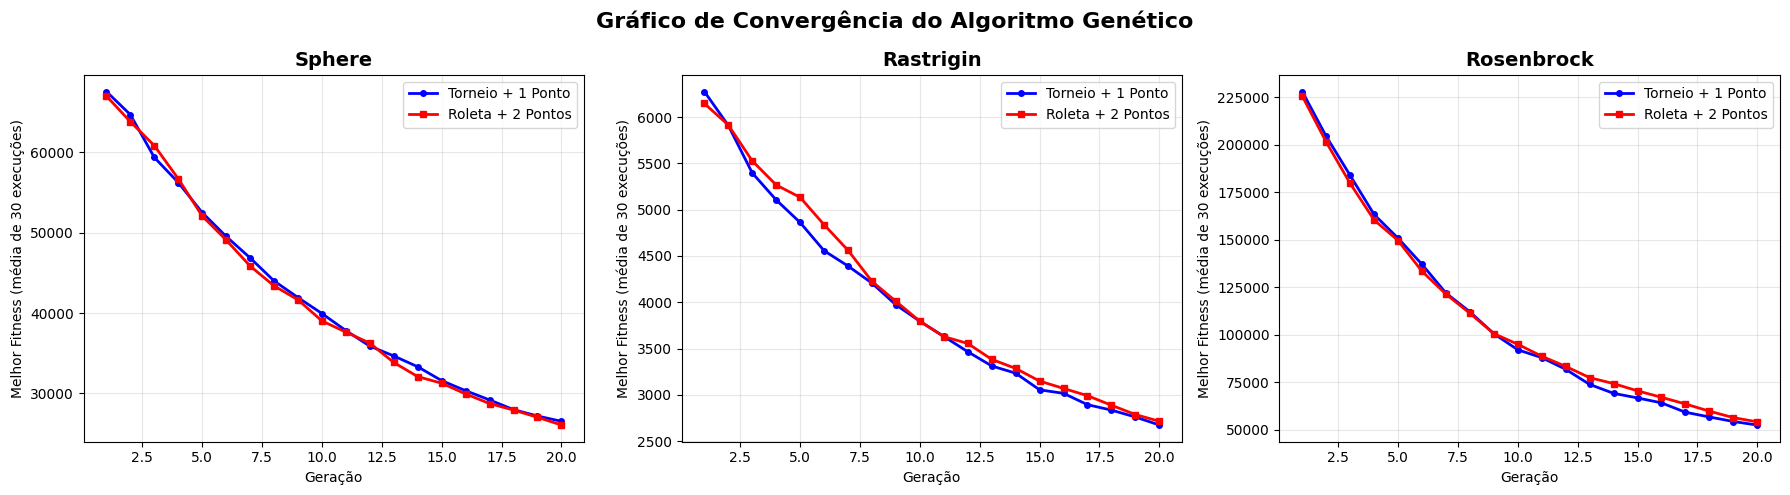

Gráfico salvo como 'convergencia.png'


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, nome in enumerate(problemas.keys()):
    ax = axes[idx]

    historicos_t = resultados_torneio_1pt[nome]["historicos"]
    media_t = np.mean(historicos_t, axis=0)
    ax.plot(range(1, N_GERACOES + 1), media_t, 'b-o', markersize=4,
            label='Torneio + 1 Ponto', linewidth=2)

    historicos_r = resultados_roleta_2pt[nome]["historicos"]
    media_r = np.mean(historicos_r, axis=0)
    ax.plot(range(1, N_GERACOES + 1), media_r, 'r-s', markersize=4,
            label='Roleta + 2 Pontos', linewidth=2)

    ax.set_title(f'{nome}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Geração')
    ax.set_ylabel('Melhor Fitness (média de 30 execuções)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Gráfico de Convergência do Algoritmo Genético', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('convergencia.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'convergencia.png'")

## 12. Boxplot dos Resultados — AG

Distribuição dos fitness finais obtidos nas 30 execuções independentes.

/tmp/ipykernel_3357/2670974199.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados, labels=labels, patch_artist=True,
/tmp/ipykernel_3357/2670974199.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados, labels=labels, patch_artist=True,
/tmp/ipykernel_3357/2670974199.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados, labels=labels, patch_artist=True,


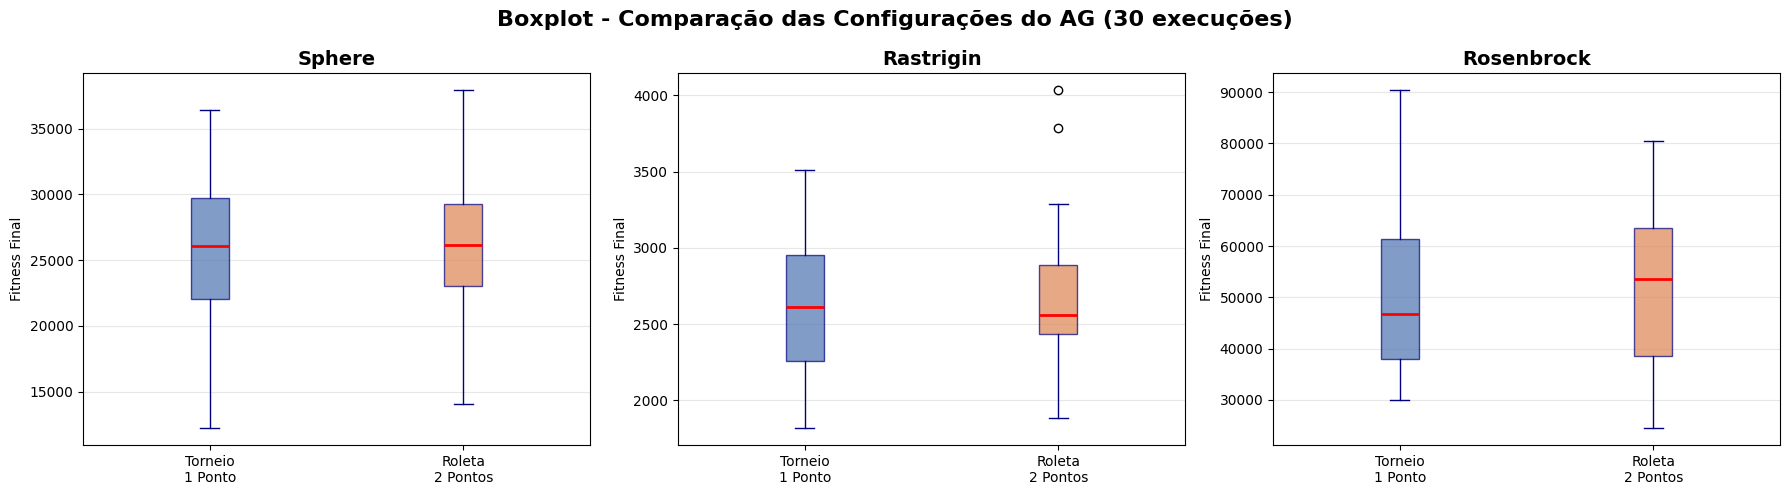

Gráfico salvo como 'boxplot.png'


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, nome in enumerate(problemas.keys()):
    ax = axes[idx]

    dados = [
        resultados_torneio_1pt[nome]["fitness_finais"],
        resultados_roleta_2pt[nome]["fitness_finais"]
    ]
    labels = ['Torneio\n1 Ponto', 'Roleta\n2 Pontos']

    bp = ax.boxplot(dados, labels=labels, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(color='navy'),
                    capprops=dict(color='navy'))

    cores = ['#4C72B0', '#DD8452']
    for patch, cor in zip(bp['boxes'], cores):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)

    ax.set_title(f'{nome}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Fitness Final')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Boxplot - Comparação das Configurações do AG (30 execuções)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'boxplot.png'")

## 13. Tabela Resumo — AG

In [ ]:
print(f"{'='*90}")
print(f"{'TABELA RESUMO DOS RESULTADOS':^90}")
print(f"{'='*90}")
print(f"{'Função':<15} {'Configuração':<25} {'Melhor':<15} {'Média':<15} {'Desvio Pad.':<15} {'Pior':<15}")
print(f"{'-'*90}")

for nome in problemas.keys():
    fit_t = resultados_torneio_1pt[nome]["fitness_finais"]
    print(f"{nome:<15} {'Torneio + 1pt':<25} {min(fit_t):<15.4f} {np.mean(fit_t):<15.4f} {np.std(fit_t):<15.4f} {max(fit_t):<15.4f}")

    fit_r = resultados_roleta_2pt[nome]["fitness_finais"]
    print(f"{'':<15} {'Roleta + 2pts':<25} {min(fit_r):<15.4f} {np.mean(fit_r):<15.4f} {np.std(fit_r):<15.4f} {max(fit_r):<15.4f}")
    print(f"{'-'*90}")

print(f"\nNúmero de execuções independentes: {N_EXECUCOES}")
print(f"Todas as funções têm ótimo global = 0.0")

                               TABELA RESUMO DOS RESULTADOS                               
Função          Configuração              Melhor          Média           Desvio Pad.     Pior           
------------------------------------------------------------------------------------------
Sphere          Torneio + 1pt             12219.7489      25462.7857      5405.3707       36392.6093     
                Roleta + 2pts             14086.0097      25703.9450      5301.1330       37920.9189     
------------------------------------------------------------------------------------------
Rastrigin       Torneio + 1pt             1816.9243       2596.3110       438.0750        3508.9314      
                Roleta + 2pts             1882.3404       2658.8676       468.5832        4033.7978      
------------------------------------------------------------------------------------------
Rosenbrock      Torneio + 1pt             29982.1668      49223.9983      14367.2094      90380.0264     


---

# Parte 2 — Particle Swarm Optimization (PSO)

### Componentes implementados:
- Geração aleatória do enxame (posição + velocidade com 20% dos limites)
- Atualização de velocidade com fator de inércia (w, c1, c2)
- Inércia constante e inércia com decaimento linear
- Cooperação global (gbest) e atualização de posição
- Gráfico de convergência e Boxplot

## 14. Geração do Enxame

Cada partícula é composta por uma **posição** e uma **velocidade**, ambas vetores de valores reais.

- **Posição:** gerada aleatoriamente dentro dos limites do problema.
- **Velocidade:** pode ser inicializada seguindo os limites completos do problema ou restrita a **20% dos limites totais** — estratégia que evita movimentação excessiva nas primeiras iterações.

In [ ]:
def gerar_enxame(n_particulas, n_genes, var_min, var_max, frac_vel=0.2):
    """
    Gera posições e velocidades iniciais do enxame.
    frac_vel: fração dos limites usada para inicializar a velocidade (padrão 20%).
    """
    vel_max = (var_max - var_min) * frac_vel

    posicoes    = [[random.uniform(var_min, var_max) for _ in range(n_genes)]
                   for _ in range(n_particulas)]
    velocidades = [[random.uniform(-vel_max, vel_max) for _ in range(n_genes)]
                   for _ in range(n_particulas)]
    return posicoes, velocidades


# Teste rápido
pos_teste, vel_teste = gerar_enxame(3, 6, -10, 10)
for i, (p, v) in enumerate(zip(pos_teste, vel_teste)):
    print(f"Partícula {i+1}:")
    print(f"  Posição:    {[round(x, 2) for x in p]}")
    print(f"  Velocidade: {[round(x, 2) for x in v]}")

Partícula 1:
  Posição:    [-6.56, 4.65, -0.5, -2.12, 5.14, 4.47]
  Velocidade: [0.68, -0.74, 2.39, -3.32, 2.35, -2.08]
Partícula 2:
  Posição:    [-0.12, -1.97, -9.16, 0.7, 2.32, -2.63]
  Velocidade: [2.35, -2.47, -0.08, -1.02, -1.45, -0.99]
Partícula 3:
  Posição:    [5.6, -9.55, -4.28, -4.35, -8.06, -5.74]
  Velocidade: [-2.0, 0.61, 2.38, -3.86, -2.04, -3.93]


## 15. Avaliação (Fitness)

Cada partícula é avaliada pela função objetivo.  
Como estamos **minimizando**, o melhor indivíduo é aquele com **menor** valor de fitness.

Além do fitness atual, cada partícula registra seu **pbest** (melhor posição já visitada por ela).

In [ ]:
def avaliar_enxame(posicoes, funcao_objetivo):
    """Retorna o fitness de cada partícula e inicializa o pbest."""
    fitness    = [funcao_objetivo(p) for p in posicoes]
    pbest_pos  = [p[:] for p in posicoes]
    pbest_fit  = fitness[:]
    return fitness, pbest_pos, pbest_fit


# Teste
fit_teste, pbest_pos_teste, pbest_fit_teste = avaliar_enxame(pos_teste, sphere)
for i, (fit, pb) in enumerate(zip(fit_teste, pbest_fit_teste)):
    print(f"Partícula {i+1}: Fitness = {fit:.4f} | pbest = {fit:.4f}")

Partícula 1: Fitness = 115.7826 | pbest = 115.7826
Partícula 2: Fitness = 100.6116 | pbest = 100.6116
Partícula 3: Fitness = 257.5714 | pbest = 257.5714


## 16. Atualização de Velocidade

A velocidade é o mecanismo central do PSO. Ela determina para onde cada partícula se move no próximo passo.

### 5.1 Fórmula

```
nova_velocidade = w * velocidade_atual
               + c1 * rand() * (pbest - posicao_atual)
               + c2 * rand() * (gbest - posicao_atual)
```

- **w** → Fator de inércia: controla quanto da velocidade anterior é mantida.
- **c1** → Coeficiente cognitivo: atração pela melhor posição própria (pbest). Valor padrão: 2.05.
- **c2** → Coeficiente social: atração pela melhor posição global (gbest). Valor padrão: 2.05.

### 5.2 Fator de Inércia

O fator **w** pode ser aplicado de duas formas:

**Inércia Constante** — usa o mesmo valor durante todo o processo. Normalmente 0.8 ou 1.0.

**Decaimento Linear** — começa alto (exploração) e reduz gradualmente (refinamento):

```
w = (wMax - wMin) * ((iteracoes_totais - iteracao_atual) / iteracoes_totais) + wMin
```

In [ ]:
def calcular_inercia(tipo, iteracao, n_iteracoes, w=0.8, w_min=0.4, w_max=0.9):
    """Retorna o fator de inércia para a iteração atual."""
    if tipo == 'constante':
        return w
    # decaimento linear
    return (w_max - w_min) * ((n_iteracoes - iteracao) / n_iteracoes) + w_min


def atualizar_velocidade(velocidade, posicao, pbest, gbest,
                         w, c1, c2, vel_max):
    """Aplica a fórmula de atualização de velocidade com clamp."""
    nova_vel = []
    for d in range(len(velocidade)):
        r1, r2 = random.random(), random.random()
        v = (w  * velocidade[d]
             + c1 * r1 * (pbest[d] - posicao[d])
             + c2 * r2 * (gbest[d] - posicao[d]))
        nova_vel.append(max(-vel_max, min(vel_max, v)))
    return nova_vel


# Teste — comparar inércia constante vs decaimento linear ao longo das iterações
print("Inércia por iteração (constante=0.8 | linear: 0.9→0.4):")
for it in [1, 5, 10, 15, 20]:
    w_c = calcular_inercia('constante', it, 20)
    w_l = calcular_inercia('linear',    it, 20)
    print(f"  Iteração {it:>2}: constante={w_c:.2f}  linear={w_l:.3f}")

Inércia por iteração (constante=0.8 | linear: 0.9→0.4):
  Iteração  1: constante=0.80  linear=0.875
  Iteração  5: constante=0.80  linear=0.775
  Iteração 10: constante=0.80  linear=0.650
  Iteração 15: constante=0.80  linear=0.525
  Iteração 20: constante=0.80  linear=0.400


## 17. Atualização de Posição e Cooperação Global

### 6.1 Nova Posição

A nova posição é simplesmente a posição atual somada à nova velocidade:

```
nova_posicao = posicao_atual + nova_velocidade
```

A posição também é limitada (clamped) aos limites do problema.

### 6.2 Cooperação Global (gbest)

Na cooperação global, **todas as partículas conhecem a melhor solução encontrada pelo enxame**.  
O gbest é atualizado sempre que uma partícula encontra uma posição com fitness menor que o melhor global até então.

In [ ]:
def atualizar_posicao(posicao, velocidade, var_min, var_max):
    """Calcula a nova posição com clamp nos limites."""
    return [max(var_min, min(var_max, posicao[d] + velocidade[d]))
            for d in range(len(posicao))]


def atualizar_pbest_gbest(posicao, fitness, pbest_pos, pbest_fit, gbest_pos, gbest_fit):
    """Atualiza o pbest da partícula e o gbest do enxame, se necessário."""
    if fitness < pbest_fit:
        pbest_fit = fitness
        pbest_pos = posicao[:]
    if fitness < gbest_fit:
        gbest_fit = fitness
        gbest_pos = posicao[:]
    return pbest_pos, pbest_fit, gbest_pos, gbest_fit


# Teste
p_atual = [1.5, -2.0, 3.0]
v_atual = [0.5, -0.3, 0.1]
p_nova  = atualizar_posicao(p_atual, v_atual, -5, 5)
print(f"Posição atual:  {p_atual}")
print(f"Velocidade:     {v_atual}")
print(f"Nova posição:   {[round(x, 2) for x in p_nova]}")

Posição atual:  [1.5, -2.0, 3.0]
Velocidade:     [0.5, -0.3, 0.1]
Nova posição:   [2.0, -2.3, 3.1]


## 18. Algoritmo PSO Completo

Junta todas as etapas do fluxograma:
1. Gerar o enxame (posições e velocidades)
2. Avaliar cada partícula e definir pbest e gbest iniciais
3. Para cada iteração:
   - Calcular o fator de inércia (constante ou linear)
   - Atualizar velocidade de cada partícula
   - Atualizar posição de cada partícula
   - Avaliar e atualizar pbest e gbest
4. Repetir até atingir o número de iterações

In [ ]:
def pso(
    funcao_objetivo,
    n_genes=30,
    var_min=-100,
    var_max=100,
    n_particulas=30,
    n_iteracoes=20,
    w=0.8,
    c1=2.05,
    c2=2.05,
    tipo_inercia='constante',
    w_min=0.4,
    w_max=0.9,
    frac_vel=0.2
):
    vel_max = (var_max - var_min) * frac_vel

    posicoes, velocidades = gerar_enxame(n_particulas, n_genes, var_min, var_max, frac_vel)
    fitness, pbest_pos, pbest_fit = avaliar_enxame(posicoes, funcao_objetivo)

    gbest_idx = int(np.argmin(pbest_fit))
    gbest_pos = pbest_pos[gbest_idx][:]
    gbest_fit = pbest_fit[gbest_idx]

    historico_melhor = []
    historico_media  = []

    for iteracao in range(1, n_iteracoes + 1):
        w_atual = calcular_inercia(tipo_inercia, iteracao, n_iteracoes, w, w_min, w_max)

        for i in range(n_particulas):
            velocidades[i] = atualizar_velocidade(
                velocidades[i], posicoes[i], pbest_pos[i], gbest_pos,
                w_atual, c1, c2, vel_max
            )
            posicoes[i] = atualizar_posicao(posicoes[i], velocidades[i], var_min, var_max)

            fit = funcao_objetivo(posicoes[i])
            pbest_pos[i], pbest_fit[i], gbest_pos, gbest_fit = atualizar_pbest_gbest(
                posicoes[i], fit, pbest_pos[i], pbest_fit[i], gbest_pos, gbest_fit
            )

        historico_melhor.append(gbest_fit)
        historico_media.append(np.mean(pbest_fit))

    return gbest_pos, gbest_fit, historico_melhor, historico_media

## 19. Configuração do PSO

In [ ]:
N_PARTICULAS = 30
N_ITERACOES  = 20
C1           = 2.05
C2           = 2.05

print("Parâmetros PSO:")
print(f"  Partículas:           {N_PARTICULAS}")
print(f"  Iterações:            {N_ITERACOES}")
print(f"  Coef. cognitivo (c1): {C1}")
print(f"  Coef. social (c2):    {C2}")
print(f"  Execuções indep.:     {N_EXECUCOES}")

Parâmetros PSO:
  Partículas:           30
  Iterações:            20
  Coef. cognitivo (c1): 2.05
  Coef. social (c2):    2.05
  Execuções indep.:     30


## 20. Execução do PSO — Inércia Constante (w = 0.8)

In [ ]:
resultados_constante = {}

for nome, config in problemas.items():
    print(f"\n{'='*60}")
    print(f"Problema: {nome} | Inércia: Constante (w=0.8)")
    print(f"{'='*60}")

    todos_fitness = []
    todos_historicos = []

    for _ in range(N_EXECUCOES):
        _, melhor_fit, hist_melhor, _ = pso(
            funcao_objetivo=config["funcao"],
            n_genes=config["n_genes"],
            var_min=config["var_min"],
            var_max=config["var_max"],
            n_particulas=N_PARTICULAS,
            n_iteracoes=N_ITERACOES,
            w=0.8,
            c1=C1,
            c2=C2,
            tipo_inercia='constante',
        )
        todos_fitness.append(melhor_fit)
        todos_historicos.append(hist_melhor)

    resultados_constante[nome] = {
        "fitness_finais": todos_fitness,
        "historicos": todos_historicos
    }

    print(f"  Melhor fitness:  {min(todos_fitness):.4f}")
    print(f"  Pior fitness:    {max(todos_fitness):.4f}")
    print(f"  Média fitness:   {np.mean(todos_fitness):.4f}")
    print(f"  Desvio padrão:   {np.std(todos_fitness):.4f}")
    print(f"  Ótimo global:    {config['otimo_global']}")


Problema: Sphere | Inércia: Constante (w=0.8)
  Melhor fitness:  3967.4689
  Pior fitness:    7567.6126
  Média fitness:   5616.0822
  Desvio padrão:   916.5976
  Ótimo global:    0.0

Problema: Rastrigin | Inércia: Constante (w=0.8)
  Melhor fitness:  695.0150
  Pior fitness:    1010.0384
  Média fitness:   841.8151
  Desvio padrão:   75.1521
  Ótimo global:    0.0

Problema: Rosenbrock | Inércia: Constante (w=0.8)
  Melhor fitness:  1921.2630
  Pior fitness:    6435.6479
  Média fitness:   3836.4732
  Desvio padrão:   899.3119
  Ótimo global:    0.0


## 21. Execução do PSO — Decaimento Linear (0.9 → 0.4)

In [ ]:
resultados_linear = {}

for nome, config in problemas.items():
    print(f"\n{'='*60}")
    print(f"Problema: {nome} | Inércia: Decaimento Linear (0.9 → 0.4)")
    print(f"{'='*60}")

    todos_fitness = []
    todos_historicos = []

    for _ in range(N_EXECUCOES):
        _, melhor_fit, hist_melhor, _ = pso(
            funcao_objetivo=config["funcao"],
            n_genes=config["n_genes"],
            var_min=config["var_min"],
            var_max=config["var_max"],
            n_particulas=N_PARTICULAS,
            n_iteracoes=N_ITERACOES,
            c1=C1,
            c2=C2,
            tipo_inercia='linear',
            w_min=0.4,
            w_max=0.9,
        )
        todos_fitness.append(melhor_fit)
        todos_historicos.append(hist_melhor)

    resultados_linear[nome] = {
        "fitness_finais": todos_fitness,
        "historicos": todos_historicos
    }

    print(f"  Melhor fitness:  {min(todos_fitness):.4f}")
    print(f"  Pior fitness:    {max(todos_fitness):.4f}")
    print(f"  Média fitness:   {np.mean(todos_fitness):.4f}")
    print(f"  Desvio padrão:   {np.std(todos_fitness):.4f}")
    print(f"  Ótimo global:    {config['otimo_global']}")


Problema: Sphere | Inércia: Decaimento Linear (0.9 → 0.4)
  Melhor fitness:  2548.8087
  Pior fitness:    4861.5232
  Média fitness:   3766.0164
  Desvio padrão:   685.4266
  Ótimo global:    0.0

Problema: Rastrigin | Inércia: Decaimento Linear (0.9 → 0.4)
  Melhor fitness:  411.2625
  Pior fitness:    860.3878
  Média fitness:   651.0434
  Desvio padrão:   72.2290
  Ótimo global:    0.0

Problema: Rosenbrock | Inércia: Decaimento Linear (0.9 → 0.4)
  Melhor fitness:  1155.8716
  Pior fitness:    3999.4024
  Média fitness:   2225.4445
  Desvio padrão:   729.7665
  Ótimo global:    0.0


## 22. Gráfico de Convergência — PSO

Evolução do melhor fitness ao longo das iterações para cada função.

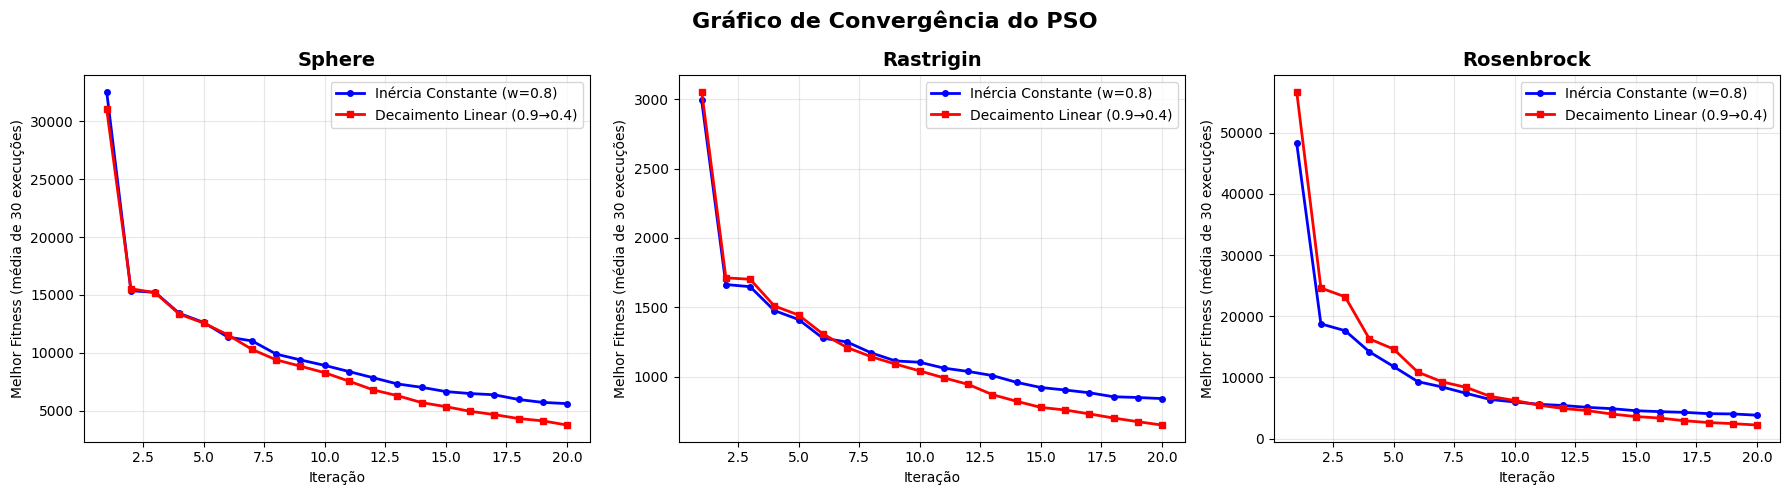

Gráfico salvo como 'convergencia_pso.png'


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, nome in enumerate(problemas.keys()):
    ax = axes[idx]

    media_c = np.mean(resultados_constante[nome]["historicos"], axis=0)
    media_l = np.mean(resultados_linear[nome]["historicos"], axis=0)

    ax.plot(range(1, N_ITERACOES + 1), media_c, 'b-o', markersize=4,
            label='Inércia Constante (w=0.8)', linewidth=2)
    ax.plot(range(1, N_ITERACOES + 1), media_l, 'r-s', markersize=4,
            label='Decaimento Linear (0.9→0.4)', linewidth=2)

    ax.set_title(f'{nome}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Iteração')
    ax.set_ylabel('Melhor Fitness (média de 30 execuções)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Gráfico de Convergência do PSO', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('convergencia_pso.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'convergencia_pso.png'")

## 23. Boxplot dos Resultados — PSO

Distribuição dos fitness finais obtidos nas 30 execuções independentes.

/tmp/ipykernel_3357/1096313544.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados, labels=labels, patch_artist=True,
/tmp/ipykernel_3357/1096313544.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados, labels=labels, patch_artist=True,
/tmp/ipykernel_3357/1096313544.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados, labels=labels, patch_artist=True,


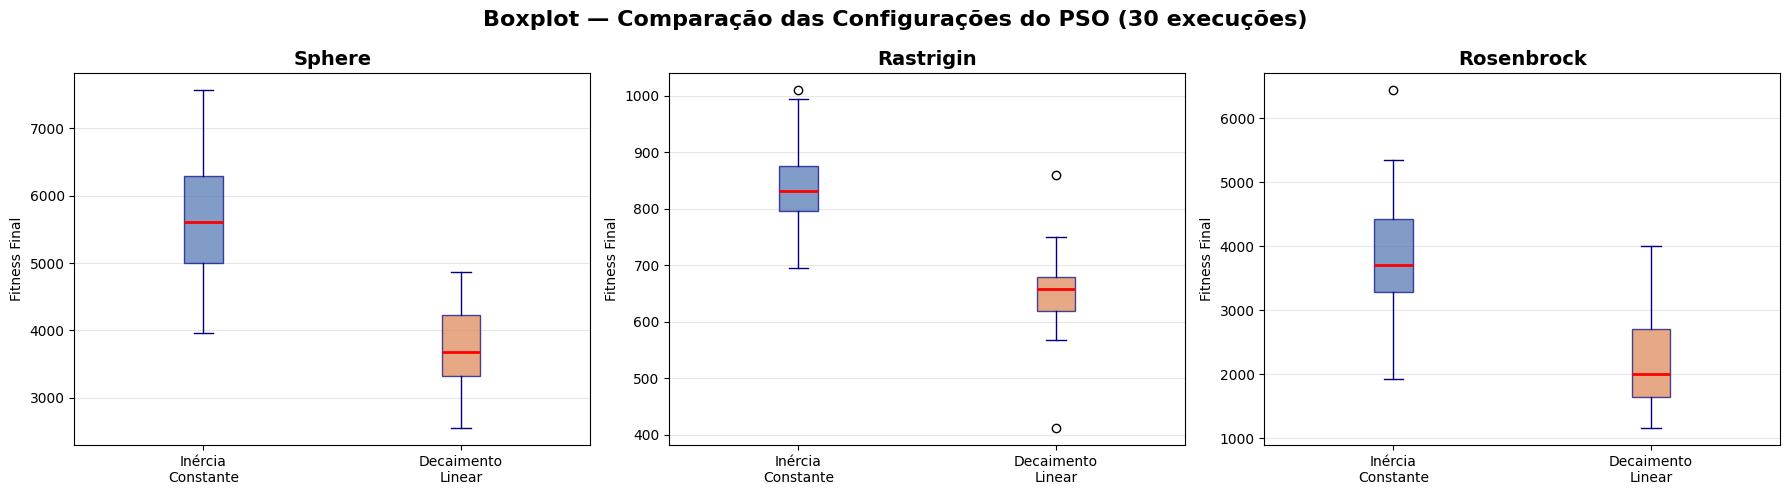

Gráfico salvo como 'boxplot_pso.png'


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, nome in enumerate(problemas.keys()):
    ax = axes[idx]

    dados  = [
        resultados_constante[nome]["fitness_finais"],
        resultados_linear[nome]["fitness_finais"]
    ]
    labels = ['Inércia\nConstante', 'Decaimento\nLinear']

    bp = ax.boxplot(dados, labels=labels, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(color='navy'),
                    capprops=dict(color='navy'))

    cores = ['#4C72B0', '#DD8452']
    for patch, cor in zip(bp['boxes'], cores):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)

    ax.set_title(f'{nome}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Fitness Final')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Boxplot — Comparação das Configurações do PSO (30 execuções)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_pso.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'boxplot_pso.png'")

## 24. Tabela Resumo — PSO

In [ ]:
print(f"{'='*90}")
print(f"{'TABELA RESUMO DOS RESULTADOS':^90}")
print(f"{'='*90}")
print(f"{'Função':<15} {'Configuração':<28} {'Melhor':<15} {'Média':<15} {'Desvio Pad.':<15} {'Pior':<12}")
print(f"{'-'*90}")

for nome in problemas.keys():
    fit_c = resultados_constante[nome]["fitness_finais"]
    print(f"{nome:<15} {'Inércia Constante':<28} {min(fit_c):<15.4f} {np.mean(fit_c):<15.4f} {np.std(fit_c):<15.4f} {max(fit_c):<12.4f}")

    fit_l = resultados_linear[nome]["fitness_finais"]
    print(f"{'':<15} {'Decaimento Linear':<28} {min(fit_l):<15.4f} {np.mean(fit_l):<15.4f} {np.std(fit_l):<15.4f} {max(fit_l):<12.4f}")
    print(f"{'-'*90}")

print(f"\nNúmero de execuções independentes: {N_EXECUCOES}")
print(f"Todas as funções têm ótimo global = 0.0")

                               TABELA RESUMO DOS RESULTADOS                               
Função          Configuração                 Melhor          Média           Desvio Pad.     Pior        
------------------------------------------------------------------------------------------
Sphere          Inércia Constante            3967.4689       5616.0822       916.5976        7567.6126   
                Decaimento Linear            2548.8087       3766.0164       685.4266        4861.5232   
------------------------------------------------------------------------------------------
Rastrigin       Inércia Constante            695.0150        841.8151        75.1521         1010.0384   
                Decaimento Linear            411.2625        651.0434        72.2290         860.3878    
------------------------------------------------------------------------------------------
Rosenbrock      Inércia Constante            1921.2630       3836.4732       899.3119        6435.6479   


---

# Parte 3 — Comparação AG × PSO

Comparação direta entre as configurações do AG e do PSO nas três funções benchmark.

## 25. Gráfico de Convergência — AG vs PSO

/tmp/ipykernel_3357/3236093544.py:13: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-s" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(iters, media_r, 'b-s', markersize=4, linewidth=2, label='AG — Roleta+2pts', linestyle='--')
/tmp/ipykernel_3357/3236093544.py:15: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r-^" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(iters, media_l, 'r-^', markersize=4, linewidth=2, label='PSO — Linear', linestyle='--')


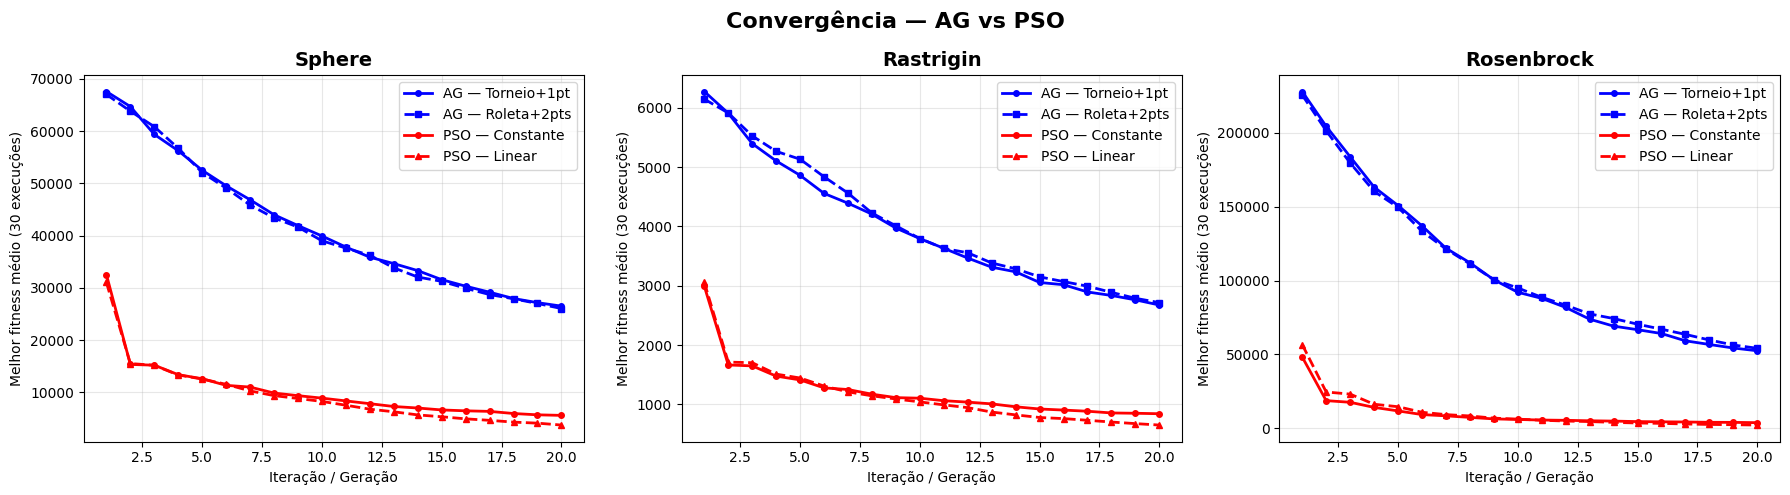

Gráfico salvo como 'convergencia_comparacao.png'


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, nome in enumerate(problemas.keys()):
    ax = axes[idx]
    iters = range(1, N_GERACOES + 1)

    media_t  = np.mean(resultados_torneio_1pt[nome]["historicos"], axis=0)
    media_r  = np.mean(resultados_roleta_2pt[nome]["historicos"], axis=0)
    media_c  = np.mean(resultados_constante[nome]["historicos"], axis=0)
    media_l  = np.mean(resultados_linear[nome]["historicos"], axis=0)

    ax.plot(iters, media_t, 'b-o', markersize=4, linewidth=2, label='AG — Torneio+1pt')
    ax.plot(iters, media_r, 'b-s', markersize=4, linewidth=2, label='AG — Roleta+2pts', linestyle='--')
    ax.plot(iters, media_c, 'r-o', markersize=4, linewidth=2, label='PSO — Constante')
    ax.plot(iters, media_l, 'r-^', markersize=4, linewidth=2, label='PSO — Linear', linestyle='--')

    ax.set_title(nome, fontsize=14, fontweight='bold')
    ax.set_xlabel('Iteração / Geração')
    ax.set_ylabel('Melhor fitness médio (30 execuções)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Convergência — AG vs PSO', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('convergencia_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'convergencia_comparacao.png'")

## 26. Boxplot — AG vs PSO

/tmp/ipykernel_3357/3443025239.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados, labels=labels, patch_artist=True,
/tmp/ipykernel_3357/3443025239.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados, labels=labels, patch_artist=True,
/tmp/ipykernel_3357/3443025239.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados, labels=labels, patch_artist=True,


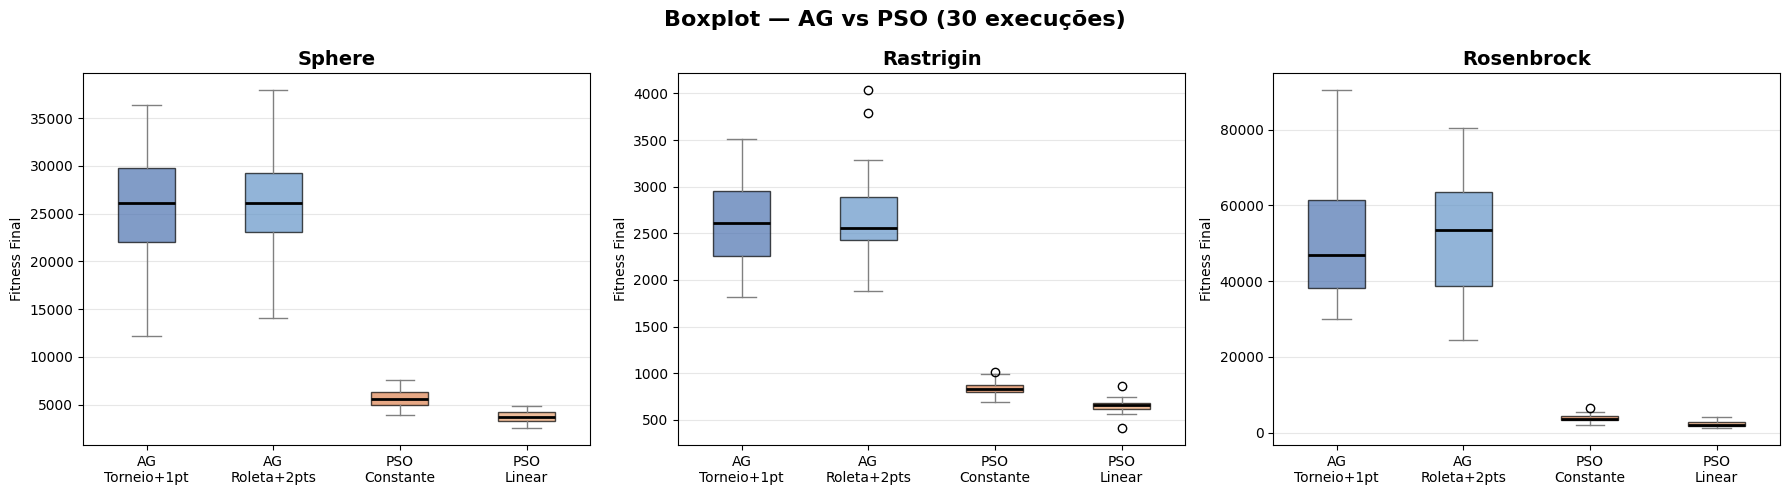

Gráfico salvo como 'boxplot_comparacao.png'


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, nome in enumerate(problemas.keys()):
    ax = axes[idx]
    dados  = [
        resultados_torneio_1pt[nome]["fitness_finais"],
        resultados_roleta_2pt[nome]["fitness_finais"],
        resultados_constante[nome]["fitness_finais"],
        resultados_linear[nome]["fitness_finais"],
    ]
    labels = ['AG\nTorneio+1pt', 'AG\nRoleta+2pts', 'PSO\nConstante', 'PSO\nLinear']

    bp = ax.boxplot(dados, labels=labels, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(color='gray'),
                    capprops=dict(color='gray'))

    cores = ['#4C72B0', '#6495C8', '#DD8452', '#E8A070']
    for patch, cor in zip(bp['boxes'], cores):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)

    ax.set_title(nome, fontsize=14, fontweight='bold')
    ax.set_ylabel('Fitness Final')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Boxplot — AG vs PSO (30 execuções)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'boxplot_comparacao.png'")

## 27. Tabela Comparativa Final

In [ ]:
configs = [
    ('AG — Torneio+1pt', resultados_torneio_1pt),
    ('AG — Roleta+2pts', resultados_roleta_2pt),
    ('PSO — Constante',  resultados_constante),
    ('PSO — Linear',     resultados_linear),
]

print(f"{'='*90}")
print(f"{'TABELA COMPARATIVA FINAL':^90}")
print(f"{'='*90}")
print(f"{'Função':<15} {'Algoritmo':<25} {'Melhor':<15} {'Média':<15} {'Desvio Pad.':<15} {'Pior':<10}")
print(f"{'-'*90}")

for nome in problemas.keys():
    for label, res in configs:
        fits = res[nome]["fitness_finais"]
        print(f"{nome:<15} {label:<25} {min(fits):<15.4f} {np.mean(fits):<15.4f} {np.std(fits):<15.4f} {max(fits):<10.4f}")
    print(f"{'-'*90}")

print(f"\nNúmero de execuções independentes: {N_EXECUCOES}")
print(f"Todas as funções têm ótimo global = 0.0")

                                 TABELA COMPARATIVA FINAL                                 
Função          Algoritmo                 Melhor          Média           Desvio Pad.     Pior      
------------------------------------------------------------------------------------------
Sphere          AG — Torneio+1pt          12219.7489      25462.7857      5405.3707       36392.6093
Sphere          AG — Roleta+2pts          14086.0097      25703.9450      5301.1330       37920.9189
Sphere          PSO — Constante           3967.4689       5616.0822       916.5976        7567.6126 
Sphere          PSO — Linear              2548.8087       3766.0164       685.4266        4861.5232 
------------------------------------------------------------------------------------------
Rastrigin       AG — Torneio+1pt          1816.9243       2596.3110       438.0750        3508.9314 
Rastrigin       AG — Roleta+2pts          1882.3404       2658.8676       468.5832        4033.7978 
Rastrigin       PSO 